In [1]:
!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

fatal: destination path 'rectified-flow' already exists and is not an empty directory.
/Users/saptarshiroy/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/My Drive/rectified_flow/clustRF/rectified-flow


In [2]:
import torch
import os
import sys
import ot
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from rectified_flow.samplers import SDESampler

from RFmodules import emd2_multivariate as W2

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:

NUM_STEPS = 1024 # Training time steps
BATCH_SIZE = NUM_STEPS + 1 # 1024
NUM_SAMPLES = 1000 # Number of generated samples

D_list = [10, 30, 50, 100, 200, 500, 1000] # List of input dimension 
RANK = 2 # Effective rank of the data distributions


# Lists for collecting the W2 distance for varying dimensions
W2_ode_geom = []
W2_ode_lin = []

W2_sde_geom = []
W2_sde_lin = []


# creating time grid 
geom_timegrid = np.zeros(NUM_STEPS + 1)
h = np.power(NUM_STEPS/2, 2/(NUM_STEPS-2)) - 1.0
# First partition [0, 1/2]
geom_timegrid[0] = 0
geom_timegrid[1] = 1.0 / NUM_STEPS
for j in range(2, NUM_STEPS // 2 + 1):
    geom_timegrid[j] = (1 + h) * geom_timegrid[j - 1]

# Second partition [1/2, 1]
geom_timegrid[NUM_STEPS] = 1.0
geom_timegrid[NUM_STEPS - 1] = 1.0 - 1.0 / NUM_STEPS
for j in range(NUM_STEPS - 2, NUM_STEPS // 2 - 1, -1):
    geom_timegrid[j] = 1.0 - (1 + h) * (1.0 - geom_timegrid[j + 1])
geom_timegrid = torch.tensor(geom_timegrid, device = device)


lin_timegrid = torch.linspace(0,1 , NUM_STEPS+1).to(device)

In [5]:
def rf_trainer(rectified_flow, D0, D1, n_samples = 10000, label = "loss", batch_size = BATCH_SIZE, time_grid = 'geometric'):
    '''
    rectified_flow = custom velocity model
    D0, D1 = toch.tensors of source and target distribution.
    n_samples = number of training samples from source and targt distributions
    batch_size = Batch size during training
    time_grid = Linear of geometric time grid used for training
    '''

    
    model = rectified_flow.velocity_field
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []

    for step in range(5000):
        optimizer.zero_grad()
        idx = torch.randperm(n_samples)[:batch_size]
        x_0 = D0[idx].to(device)
        x_1 = D1[idx].to(device)

        if time_grid == 'geometric':
            loss = rectified_flow.get_loss(x_0, x_1)#, t = geom_timegrid)
        if time_grid == 'linear':
            loss = rectified_flow.get_loss(x_0, x_1)#, t = lin_timegrid)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if step % 1000 == 0:
            print(f"Epoch {step}, Loss: {loss.item()}")

    plt.plot(losses, label=label)
    plt.legend()
    
from rectified_flow.samplers.base_sampler import Sampler



class MyEulerSampler(Sampler):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def step(self, **model_kwargs):
        # Extract the current time, next time point, and current state
        t, t_next, x_t = self.t, self.t_next, self.x_t
        
        # Compute the velocity field at the current state and time
        v_t = self.rectified_flow.get_velocity(x_t=x_t, t=t, **model_kwargs)
        
        # Update the state using the Euler formula
        self.x_t = x_t + (t_next - t) * v_t



[14.44419246 18.82302965 15.86409618 ...  6.15007646 21.86903994
 14.51010439]
########################################
Initiating training phase for dimension: 10
########################################
Epoch 0, Loss: 58.85901641845703
Epoch 1000, Loss: 3.531687021255493
Epoch 2000, Loss: 3.287837028503418
Epoch 3000, Loss: 3.955246686935425
Epoch 4000, Loss: 3.6127448081970215
Epoch 0, Loss: 3.9068593978881836
Epoch 1000, Loss: 3.224773645401001
Epoch 2000, Loss: 3.4838545322418213
Epoch 3000, Loss: 3.37980055809021
Epoch 4000, Loss: 3.492356538772583
[14.44419246 18.82302965 15.86409618 ...  6.15007646 21.86903994
 14.51010439]
########################################
Initiating training phase for dimension: 30
########################################
Epoch 0, Loss: 25.67668914794922
Epoch 1000, Loss: 1.4717011451721191
Epoch 2000, Loss: 1.5469682216644287
Epoch 3000, Loss: 1.3983384370803833
Epoch 4000, Loss: 1.3273792266845703
Epoch 0, Loss: 1.2263400554656982


KeyboardInterrupt: 

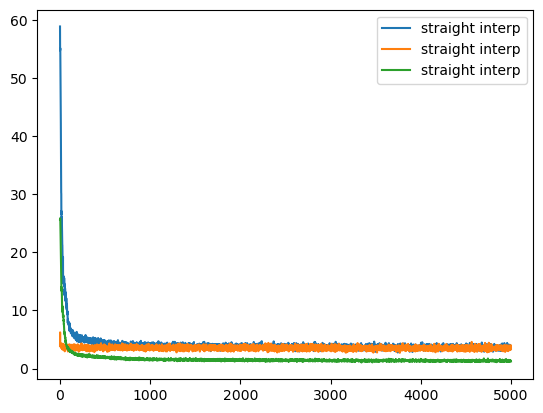

In [6]:
for INPUT_DIM in D_list:
    n_samples = 50000
    
    '''
    Generating source and traget distributions 
    '''
    # pi_0 is Standard Gaussian of dimension INPUT_DIM
    pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))

    
    ################################################################################
    # pi_1 is a spiral shaped distribution in INPUT_DIM dimensions with shifted centers
    ################################################################################
    num_turns = 20
    scale = 30
    theta = np.sqrt(np.random.rand(n_samples) * num_turns) * 2 * np.pi  # np.sqrt to ensure uniform distribution of points in the spiral
    r = theta**2/scale
    print(r)
    data = np.zeros((n_samples, INPUT_DIM))
    data[:, 0] = r * np.cos(theta) + 15.0
    data[:, 1] = r * np.sin(theta) + 5.0
    data[:, 2] = np.random.normal(0, 1, n_samples)  # add some noise in the 3rd dimension
    for d in range(3, INPUT_DIM):
        data[:, d] = 3 * np.ones(n_samples)
    data = torch.tensor(data, device=device, dtype=torch.float32)

    ################################################################################
    # #  pi_1 is mixture of 2 low-rank Gaussians with dimensionality INPUT_DIM
    ################################################################################
    # N_CLUSTERS = 2
    # CENTER1 = np.zeros(INPUT_DIM); CENTER1[0] = 15.0; CENTER1[1] = -10.0
    # CENTER2 = np.zeros(INPUT_DIM); CENTER2[0] = 15.0; CENTER2[1] = 20.0
    


    # pi_11 = gmm.LowrankGaussian(n_samples= int(n_samples/2), n_features=INPUT_DIM, rank=RANK, random_state=42)
    # pi_11.generate_data()
    # pi_12 = gmm.LowrankGaussian(n_samples=int(n_samples/2), n_features=INPUT_DIM, rank=RANK, random_state=24)
    # pi_12.generate_data()
    # data1 = torch.tensor(pi_11.data, device=device, dtype=torch.float32) + torch.tensor(CENTER1, device=device, dtype=torch.float32)
    # data2 = torch.tensor(pi_12.data, device=device, dtype=torch.float32) + torch.tensor(CENTER2, device=device, dtype=torch.float32)
    # data = torch.cat([data1, data2], dim=0)

    D0 = pi_0.sample([n_samples])   
    D1 = data
    #shuffle rows of D1
    perm = torch.randperm(D1.size(0))
    D1 = D1[perm]


    
    straight_rf = RectifiedFlow(
    data_shape=(INPUT_DIM,),
    velocity_field=MLPVelocity(INPUT_DIM, hidden_sizes = [128, 128, 128]).to(device),
    interp="straight",
    source_distribution=pi_0,
    device=device,
    )

    # straight_rf_geomgrid = RectifiedFlow(
    # data_shape=(INPUT_DIM,),
    # velocity_field=MLPVelocity(INPUT_DIM, hidden_sizes = [128, 128, 128]).to(device),
    # interp="straight",
    # source_distribution=pi_0,
    # device=device,
    # )

    # straight_rf_lingrid = RectifiedFlow(
    # data_shape=(INPUT_DIM,),
    # velocity_field=MLPVelocity(INPUT_DIM, hidden_sizes = [128, 128, 128]).to(device),
    # interp="straight",
    # source_distribution=pi_0,
    # device=device,
    # )
    print("########################################")
    print("Initiating training phase for dimension:", INPUT_DIM)
    print("########################################")

    # training phase
    rf_trainer(rectified_flow=straight_rf, D0=D0, D1=D1, n_samples=n_samples, label = 'straight interp',
               time_grid='geometric')
    rf_trainer(rectified_flow=straight_rf, D0=D0, D1=D1, n_samples=n_samples, label = 'straight interp',
               time_grid='linear')

    # ODE sampler
    
    ### sampler with geomteric time grid
    euler_sampler_geomgrid = MyEulerSampler(
    rectified_flow=straight_rf,
    num_steps=NUM_STEPS,
    num_samples=NUM_SAMPLES,
    time_grid= geom_timegrid
    )


    ### sampler with linear time grid
    euler_sampler_lineargrid = MyEulerSampler(
        rectified_flow=straight_rf,
        num_steps=NUM_STEPS,
        num_samples=NUM_SAMPLES,
        time_grid= lin_timegrid
    )
    traj_geomgrid = euler_sampler_geomgrid.sample_loop(seed=233)
    traj_lineargrid = euler_sampler_lineargrid.sample_loop(seed = 233)

    # appending W2 distances
    Dist_geomgrid = W2(traj_geomgrid.trajectories[NUM_STEPS].numpy(), D1.numpy()[:NUM_SAMPLES])
    Dist_lineargrid = W2(traj_lineargrid.trajectories[NUM_STEPS].numpy(), D1.numpy()[:NUM_SAMPLES])

    W2_ode_geom.append(Dist_geomgrid)
    W2_ode_lin.append(Dist_lineargrid)


    # SDE sampler 
    ### sampler with geometric time grid
    
    sde_sampler_geomgrid = SDESampler(
        rectified_flow=straight_rf,
        num_steps=NUM_STEPS,
        num_samples=NUM_SAMPLES,
        noise_scale = lambda t: 1/(t + 1e-6),
        noise_method = 'euler',
        ode_method = 'euler',
        noise_decay_rate = 0.0,
        time_grid = geom_timegrid
    )

    ### sampler with linear time grid
    sde_sampler_lineargrid = SDESampler(
        rectified_flow=straight_rf,
        num_steps=NUM_STEPS,
        num_samples=NUM_SAMPLES,
        noise_scale = lambda t: 1/(t + 1e-6),
        noise_method = 'euler',
        ode_method = 'euler',
        noise_decay_rate = 0.0,
        time_grid = lin_timegrid
    )

    traj_sde_geomgrid = sde_sampler_geomgrid.sample_loop(seed=0)
    traj_sde_lineargrid = sde_sampler_lineargrid.sample_loop(seed = 0)
    # appending W2 distances
    Dist_sde_geomgrid = W2(traj_sde_geomgrid.trajectories[NUM_STEPS].numpy(), D1.numpy()[:NUM_SAMPLES])
    Dist_sde_lineargrid = W2(traj_sde_lineargrid.trajectories[NUM_STEPS].numpy(), D1.numpy()[:NUM_SAMPLES]) 
    W2_sde_geom.append(Dist_sde_geomgrid)
    W2_sde_lin.append(Dist_sde_lineargrid)
    

        


In [ ]:
# Plotting W2 distances vs dimensions
plt.figure(figsize=(10,6))
plt.plot(D_list, W2_ode_geom, marker='o', label='ODE Geometric Grid')
plt.plot(D_list, W2_ode_lin, marker='o', label='ODE Linear Grid')
plt.plot(D_list, W2_sde_geom, marker = 'o', ls = '--', label='SDE Geometric Grid')
plt.plot(D_list, W2_sde_lin, marker = 'o', ls = '--', label='SDE Linear Grid')
plt.xlabel('Input Dimension')
plt.ylabel('W2 Distance')
plt.title('W2 Distance vs Input Dimension for Different Samplers and Time Grids')
plt.legend()
plt.grid()
plt.show()